<div style="background-color:#d4edda; border-left:#d4edda solid #ad1457;border-right:5px solid #d4edda; padding:10px;"><div style="text-align:center; font-size:30px;"><b>Prof - Jean-Baptiste Deloges </b></div>
  <div style="text-align:center; font-size:30px;"><b>A.ABO</b></div>
 
</div>

<div style="background-color:#ffe6cc;  padding:10px;">
    <div style="text-align:center; font-size:30px;"><b>
         UL2IN006 – Structures de données   année 2025–2026
    </b></div>
</div>

<div style="background-color:#fff3cd; border-left:2px solid #ad1457; padding:10px; margin-top:10px; ">
     <div style="text-align:center; font-size:30px;"><b>TD2 - Liste, File, Pile</b></div>

</div>

In [31]:
from IPython.display import Image
from IPython.display import HTML
HTML("<div align='center'><img src='C:/Users/Utilisateur/Desktop/sdd.png' width='500'></div>")

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX1 :</b> Liste doublement chaınee <br>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.1 :</b> D´efinir la structure d’une liste doublement chaınee
</div>

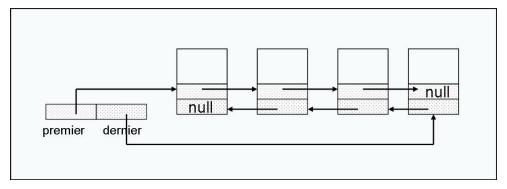

In [32]:
from IPython.display import Image
import base64

with open("C:/Users/Utilisateur/Desktop/sdd.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

display(Image(data=base64.b64decode(encoded_string)))

In [ ]:
typedef struct _Elem{
    int donne;
    struct _Elem *suiv;
    struct _Elem *prec;
}Elem;

typedef struct _list_elem{
    Elem *premier;
    Elem *dernier;
}List_elem;


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.2 :</b> Ecrire la fonction  creerElement qui cree un element de la liste. La valeur qui doit etre contenue
dans l’element est passee en parametre.

</div>

In [ ]:
Elem *cree_elem(int val){
    Elem *new= malloc(sizeof(Elem));
    new->donne=val;
    new->prec=NULL;
    new->suiv=NULL;
    return  new;
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.3 :</b>Ecrire<br> — une fonction initialiserListe qui initialise une liste deja allouee.<br>
— une fonction creerListe qui alloue, initialise et retourne une liste. <br>
— une fonction listeVide qui retourne vrai si la liste est vide, et faux dans le cas contraire.<br>

</div>

In [ ]:
void initialise_list(List_elem *l){
    l->dernier=NULL;
    l->premier=NULL;
}
List_elem *cree_list(){
    List_elem *l= malloc(sizeof(List_elem));
    initialise_list(l);
    return l;
}
int list_vide(List_elem *l){
    return (l->premier == NULL);
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.4 :</b> Ecrire la fonction insererEnTete qui insere un nouvel element en tete de liste

</div>

In [ ]:
void inserer_en_tete(List_elem *l, int val){
    if (list_vide(l)){
        Elem *e = cree_elem(val);
        l->premier = e;
        l->dernier = e;
    }else{
        Elem *e = cree_elem(val);
        e->suiv = l->premier;
        l->premier->prec = e;
        l->premier = e;
    }
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.5 :</b> Ecrire la fonction  insererEnFin qui insere un nouvel element en fin de liste.

</div>

In [ ]:
void inserer_en_fin(List_elem *l,int val){
    if (list_vide(l)){
        inserer_en_tete(l,val);
    }else{
        Elem *e = cree_elem(val);
        e->prec = l->dernier;
        l->dernier->suiv = e;
        l->dernier = e;
    }
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.6 :</b> Ecrire la fonction  afficher qui affiche une liste a l’envers

</div>

In [ ]:
void affiche(List_elem *l){
    Elem *link = l->dernier;
    while (link)
    {
        printf("val -> %d \t",link->donne);
        link = link->prec;
    }
    printf("\n");
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.7 :</b> Ecrire la fonction  rechercher qui recherche si une valeur est presente dans la liste et retourne
un pointeur sur l’element correspondant s’il existe, et NULL s’il n’est pas trouve.

</div>

In [ ]:
Elem *recherche_elem(List_elem *l,int val){
    Elem *link = l->premier;

    while(link){
        if (link->donne == val)return link;
        link = link->suiv;
    }
    return NULL;
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.8 :</b>  Ecrire la fonction supprimerElement qui enleve d’une liste un l’element pour lequel on passe
un pointeur en parametre : on considere que cette fonction ne sera utilisee qu’avec le pre-requis que
le pointeur sur element n’est pas NULL et qu’il pointe sur un element de la liste.
</div>

In [ ]:
void supprime_elem(List_elem *l, Elem *e){
    Elem *Esuiv = e->suiv;
    Elem *Eprec = e->prec;
    if (Eprec == NULL){ 
        l->premier = Esuiv;  
        if (Esuiv != NULL){ 
            Esuiv->prec = NULL;
        }else{
            l->dernier = NULL; 
        }
    }else if (Esuiv == NULL){ 
        l->dernier = Eprec;   
        Eprec->suiv = NULL;  
    }else{
        Eprec->suiv = Esuiv;  
        Esuiv->prec = Eprec;   
    }    
    free(e);
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.9 :</b>  Ecrire les fonctions supprimerTete et supprimerFin qui permettent de supprimer le debut et
la fin d’une liste respectivement, et de retourner leur valeur
</div>

In [ ]:
int supprime_deb(List_elem *l){
    Elem *temp = l->premier;
    int i = l->premier->donne;

    if (l->premier == NULL) return -1; // for empty list
    if (l->premier->suiv == NULL) { l->premier = l->dernier = NULL; free(temp); return i; }
    l->premier = l->premier->suiv;
    l->premier->prec= NULL;
    free(temp);
    return i;
}
int supprime_fin(List_elem *l){
    int i = l->dernier->donne;
    Elem *temp = l->dernier;

    if (l->premier == NULL) return -1; // for empty list
    if (l->premier->suiv == NULL) { l->premier = l->dernier = NULL; free(temp); return i; }
    l->dernier= l->dernier->prec;
    l->dernier->suiv = NULL;
    free(temp);
    return i;
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.10 :</b>  Ecrire la fonction desalloueListe qui libere toute la memoire utilisee pour la liste
</div>

In [ ]:
void desalloue(List_elem *l){
    Elem *e = l->premier;
    Elem *temp;
    while(e){
        temp = e;
        e = e->suiv;
        free(temp);
    }
    free(l);
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q1.10 :  Ecrire une fonction main qui utilisent des operations d´efinies dans les questions precedentes.  </b>
</div>

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX2 : </b> Gestion de guichets   
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
Un bureau de poste a plusieurs guichets. A l’entree, vous donnez votre numero et l’operation que vous 
voulez realiser. Le prepose vous enregistre au guichet correspondant. Chaque guichet correspond ainsi
a une file d’attente. Ainsi, on aura pour chaque guichet une liste doublement chainee dans laquelle un
nouvel arrivant est ajout´e en tˆete et la personne qui sera appel´ee au guichet est en fin de liste. <br>
    <b>  Q 2.1 Quelle structure de donnees proposez-vous pour representer les guichets sachant que ceux-ci
sont numerotes de 0 a n.</b>  

  
</div>

In [ ]:
typedef struct _Guichet{
    int nb;
    List_elem **T_guichet;
}Guichet;

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.2 : </b> Ecrire la fonction  creerBureauPoste qui cree un bureau de poste a n guichets.  
</div>

In [ ]:
Guichet *cree_bureau_post(int n){
    Guichet *P = malloc(sizeof(Guichet));
    P->nb = n;
    P->T_guichet = malloc(sizeof(List_elem) * n);
    for (int i = 0 ;i < n ; i++ ){
       P->T_guichet[i] =  cree_list(P->T_guichet[i]);
    }
    return P;
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.3 : </b>Ecrire la fonction afficherPoste qui affiche pour chaque guichet la liste d’attente.  
</div>

In [ ]:
void affiche_guichet(Guichet *g){
    for (int  i = 0; i < g->nb ; i++){
         affiche(g->T_guichet[i]);
    }
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.4 : </b> Ecrire la fonction ajouterAuGuichet qui prend un bureau de poste, un numero du guichet et
le numero d’identification d’une personne, et qui ajoute la personne dans la file d’attente du guichet.
    
</div>

In [ ]:
void ajoute_Auguichet(Guichet *G, int bureau, int id){
    inserer_en_tete(G->T_guichet[bureau],id);
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.5 : </b> Ecrire la fonction appelerAuGuichet qui rend le num´ero de la premi`ere personne appel´ee `a ce
guichet et enl`eve cette personne de la liste correspondante.
</div>

In [ ]:
int appele_Au_guichet(Guichet *g, int bureau, int id){
    int  i = supprime_fin(g->T_guichet[bureau]);
    return i;
}

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX3 : </b> Evaluation d’expressions completement parenthesees
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  : </b> On propose d’ecrire un algorithme permettant d’evaluer une expression mathematique completement
parenthesee ne contenant que des operateurs binaires. Pour ce faire, on utilisera une pile, appelee
pile d’evaluation, qui contiendra des valeurs ou des operateurs. L’algorithme consiste a parcourir de
gauche a droite l’expression parenthesee et a empiler ou d´epiler des elements suivant le type de symbole
rencontre. Pour chaque symbole de l’expression on execute les instructions suivantes : <br>
— Si le symbole est une valeur, on empile cette valeur. <br>
— Si le symbole est un operateur, on empile cet operateur.<br>
— Si le symbole est une parenth`ese fermante, on d´epile les 3 premiers elements de la pile (un
operateur et deux valeurs) et on empile le resultat de l’operation.<br>
La figure 3 decrit l’evolution de la pile au cours de l’evaluation de l’expression ((5 + 2) ∗ 3).

<b> Q 3.1 : 
    Ecrivez l’algorithme qui permet d’evaluer une expression completement parenth´esee </b>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">

<pre style="background:#b7e4c7; padding:10px; border-radius:8px; color:#081c15;">
typedef struct _Pile{
    int top;
    int *tab_pile;
}Pile;

void empile(Pile *P,int val){
    P->top += 1;
    P->tab_pile[P->top] = val;
}

int depile(Pile *p){
    int i = p->top;
    p->top -= 1;
    return p->tab_pile[i];
}

Pile *cree_Pile(){
    Pile *p= malloc(sizeof(Pile));
    p->top = -1;
    p->tab_pile = malloc(sizeof(int) * 20);
    return p;
}

int parenthese(char *str){
    int a = 0;
    int b = 0;
    int res = 0;
    int op;
    Pile *pile = cree_Pile();
    for(int  i = 0; str[i] != '\0'; i++){
        if (str[i] == '+' || str[i] == '-' || str[i] == '*' || str[i] == '/' || str[i] == '%' || (str[i] >= '0' && str[i] <='9') ){
            if (str[i] >= '0' && str[i] <= '9'){
                empile(pile , str[i] - '0');
            }else{
                empile(pile,str[i]);
            }
        }else if (str[i] == ')'){
            b = depile(pile);
            op =(char) depile(pile);
            a = depile(pile);
            if (op == '+') {res = a + b;}
            else if (op == '-') {res = a - b;}
            else if (op == '*') {res = a * b;}
            else if (op == '/') {res = a / b;}
            else if (op == '%') {res = a % b;}
            empile(pile,res);
        }
    }
    return res;
}</pre>
</div>

<div style="background-color:#f8d7da; border-left:6px solid #ad1457; padding:10px; margin-top:10px; ">
     <div style="text-align:center; font-size:30px;"><b> TD 3 : Tables de hachage</b></div>

</div>

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX1 :</b> Empreintes Digitales <br>
</div>



<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  </b> On estime a 1/64 milliards la probabilite que deux individus possedent les memes empreintes digitales.
A l’echelle de la population humaine (plusieurs milliards d’individus), cette probabilite est suffisante
pour assurer une identification fiable. Une empreinte digitale est stockee sous forme d’un fichier image
(JPEG) puis traitee afin de recuperer les informations necessaires a l’identification. Ces informations
sont representees sous la forme d’une suite de six entiers compris entre 0 et 99 (par exemple, [02, 17,
24, 04, 77, 20]).
Figure 1 – Empreintes digitales
Les services de police disposent d’une banque de donnees associant une fiche personnelle (nom, prenom,
age, adresse, etc...) a une empreinte digitale.<br>
<b> Q 1.1  :</b> Quelle structure de donnees suggerez-vous pour le stockage des donnees en question ?

</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> Pour le stockage et la recherche efficaces, on peut utiliser une table de hachage (hash table) fonctionnant selon le principe clé–valeur :

Clé : l’empreinte digitale (ou un identifiant unique calculé à partir d’elle),

Valeur : la fiche personnelle associée à cet individu.
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  Q 1.2 </b> On estime `a 1/64 milliards la probabilit´e que deux individus poss`edent les mˆemes empreintes digitales.
La m´emoire des ordinateurs dont dispose les services de polices ´etant limit´ee, la taille maximale
des tableaux ne peut d´epasser 100 000. Que peut-on en d´eduire sur la fonction de hachage `a utiliser ?

</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> La fonction de hachage doit renvoyer h = clé % 100000 afin de rester dans la taille du tableau et répartir les données uniformément.
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  Q 1.3 </b> Q 1.3 Soit [x1, x2, x3, x4, x5, x6] le vecteur associ´e aux empreintes digitales d’un individu. Que pensezvous de la fonction de hachage suivante ? Comment l’am´eliorer ?<br>
 int g (int x1 , int x2 , int x3 , int x4 , int x5 , int x6 ) { <br>
         return ( x1 * x2 * x3 * x4 * x5 * x6 ) % 100000;
 }

</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> 
    Cette fonction de hachage n’est pas bonne, car le produit x1 * x2 * ... * x6 peut :

rapidement dépasser la capacité d’un entier (overflow),
produire beaucoup de collisions (plusieurs empreintes différentes donnent le même produit, surtout si un des xi vaut 0).<br>
h = (x1* 31 + x2* 37 + x3* 41 + x4* 43 + x5* 47 + x6* 53) % 100000;
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  Q 1.4 </b>  La banque de donn´ees des services de police contient les entr´ees suivantes :<br>
[02, 04, 10, 01, 00, 17]<br>
[02, 10, 00, 02, 09, 05]<br>
[00, 01, 17, 04, 02, 10]<br>
Calculer la valeur renvoy´ee par la nouvelle fonction de hachage pour chacune de ces cl´es. Qu’observet-on ? Que peut-on proposer afin de r´esoudre ce probl`eme ?
</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> 
   Les valeurs de hachage (384, 256, 362) sont très proches les unes des autres → la répartition dans la table est non uniforme.
Cela augmente le risque de collisions, surtout avec 100 000 cases
</div>

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX2 :</b> Comparaison de differents types de tables <br>
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  Q 1.4 </b>  <br>
<h2>🔢 Table des mots et leurs clés hexadécimales</h2>
<p>
On considère l’ensemble de 13 mots du tableau suivant, et on suppose qu’il existe une fonction <code>f</code>
qui associe à chaque mot une clé (valeur entière donnée en <strong>hexadécimal</strong>).
</p>

<table border="1" cellpadding="6" cellspacing="0" style="border-collapse: collapse; text-align:center; width:70%; height:20px; margin:auto;">
  <thead style="background-color:#f2f2f2;">
    <tr>
      <th>N°</th>
      <th>mot μ</th>
      <th>clé f(μ) (en hexadécimal)</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>01</td><td>le</td><td>FF2E</td></tr>
    <tr><td>02</td><td>cours</td><td>178DD38</td></tr>
    <tr><td>03</td><td>appelé</td><td>75EA33</td></tr>
    <tr><td>04</td><td>structures</td><td>35CE5</td></tr>
    <tr><td>05</td><td>de</td><td>9AA8BF1</td></tr>
    <tr><td>06</td><td>données</td><td>2738</td></tr>
    <tr><td>07</td><td>est</td><td>A4C74</td></tr>
    <tr><td>08</td><td>absolument</td><td>1CA4C74</td></tr>
    <tr><td>09</td><td>génial</td><td>14D26</td></tr>
    <tr><td>10</td><td>j’adore</td><td>5A38</td></tr>
    <tr><td>11</td><td>faire</td><td>1BAE5</td></tr>
    <tr><td>12</td><td>ses</td><td>65B4EE5</td></tr>
    <tr><td>13</td><td>TD/TME</td><td>8C74</td></tr>
  </tbody>
</table>

<b> 
Q 2.1 Nous allons utiliser la fonction de hachage g(k) = k mod 16 pour chaque cl´e k associ´ee `a un
mot. Donner en base d´ecimale, la valeur hach´ee associ´ee `a chaque cl´e du tableau.
</b>
</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> 

<p>
On applique la fonction de hachage <code>g(k) = k mod 16</code> à chaque clé <code>f(μ)</code> (en hexadécimal).<br>
Le tableau ci-dessous montre pour chaque mot sa clé hexadécimale et la valeur hachée obtenue :
</p>

<table border="1" cellpadding="6" cellspacing="0" style="border-collapse: collapse; text-align:center; width:70%; margin:auto;">
  <thead style="background-color:#f2f2f2;">
    <tr>
      <th>N°</th>
      <th>mot μ</th>
      <th>clé f(μ) (hexadécimal)</th>
      <th>g(k) = k mod 16</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>01</td><td>le</td><td>FF2E</td><td><b>14</b></td></tr>
    <tr><td>02</td><td>cours</td><td>178DD38</td><td><b>8</b></td></tr>
    <tr><td>03</td><td>appelé</td><td>75EA33</td><td><b>3</b></td></tr>
    <tr><td>04</td><td>structures</td><td>35CE5</td><td><b>5</b></td></tr>
    <tr><td>05</td><td>de</td><td>9AA8BF1</td><td><b>1</b></td></tr>
    <tr><td>06</td><td>données</td><td>2738</td><td><b>8</b></td></tr>
    <tr><td>07</td><td>est</td><td>A4C74</td><td><b>4</b></td></tr>
    <tr><td>08</td><td>absolument</td><td>1CA4C74</td><td><b>4</b></td></tr>
    <tr><td>09</td><td>génial</td><td>14D26</td><td><b>6</b></td></tr>
    <tr><td>10</td><td>j’adore</td><td>5A38</td><td><b>8</b></td></tr>
    <tr><td>11</td><td>faire</td><td>1BAE5</td><td><b>5</b></td></tr>
    <tr><td>12</td><td>ses</td><td>65B4EE5</td><td><b>5</b></td></tr>
    <tr><td>13</td><td>TD/TME</td><td>8C74</td><td><b>4</b></td></tr>
  </tbody>
</table>


</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  Q 2.2 </b>  Pour chaque type de table de hachage ci-dessous, indiquez ce que l’on obtiendrait si l’on partait
d’une table vide de taille 16 et que l’on inserait dans l’ordre tous les mots ci-dessus avec la fonction <br>
de hachage g(k) = k mod 16. <br>
1. Table de hachage avec resolution des collisions par chaınage. <br>
2. Table de hachage avec adressage ouvert et probing lineaire h(k, i) = g(k) + i.<br>
3. Table de hachage avec adressage ouvert et probing quadratique h(k, i) = g(k) + i/2 + i^2 /2

 <br>
Pour les adressages ouverts, calculez le nombre de probes `a effectuer en moyenne pour obtenir un
´el´ement donn´e dans la table. D´eduisez-en le meilleur des deux probings.
</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">

<!-- ========================================================= -->
<h3 style="color:#007acc;">1️⃣ Table de hachage avec <u>chaînage</u></h3>

<pre style="font-size:12px; line-height:1.3; border:1px solid #ccc; padding:8px; background:#fafafa;">
Case : Par chaînage
C00
C01 : de
C02
C03 : appelé
C04 : est → absolument → TD/TME
C05 : structures → faire → ses
C06 : génial
C07
C08 : cours → données → j’adore
C09
C10
C11
C12
C13
C14 : le
C15
</pre>

<p style="font-size:12px; margin-top:-5px;">
✅ <b>Remarque :</b> chaque case contient une liste chaînée. Les collisions sont simplement ajoutées à la fin de la liste.
</p>

<!-- ========================================================= -->
<h3 style="color:#007acc;">2️⃣ Table de hachage avec <u>adressage ouvert — probing linéaire</u></h3>

<pre style="font-size:12px; line-height:1.3; border:1px solid #ccc; padding:8px; background:#fafafa;">
Case : Mot : Historique des essais
C00
C01 : de : C1
C02
C03 : appelé : C3
C04 : est : C4
C05 : structures : C5
C06 : absolument : C4 → C5 → C6
C07 : génial : C6 → C7
C08 : cours : C8
C09 : données : C8 → C9
C10 : j’adore : C8 → C9 → C10
C11 : faire : C5 → C6 → C7 → C8 → C9 → C10 → C11
C12 : ses : C5 → C6 → C7 → C8 → C9 → C10 → C11 → C12
C13 : TD/TME : C4 → C5 → C6 → C7 → C8 → C9 → C10 → C11 → C12 → C13
C14 : le : C14
C15
</pre>

<p style="font-size:12px; margin-top:-5px;">
✅ <b>Remarque :</b> en cas de collision, on avance de 1 case à la fois (<code>+i</code>).
<br>Le clustering est élevé ; la moyenne est d’environ <b>3,2 sondages</b>.
</p>

<!-- ========================================================= -->
<h3 style="color:#007acc;">3️⃣ Table de hachage avec <u>adressage ouvert — probing quadratique</u></h3>

<pre style="font-size:12px; line-height:1.3; border:1px solid #ccc; padding:8px; background:#fafafa;">
Case : Mot : Historique des essais
C00 : TD/TME : C4 → C5 → C8 → C9 → C12 → C13 → C14 → C15 → C0
C01 : de : C1
C02
C03 : appelé : C3
C04 : est : C4
C05 : structures : C5
C06 : génial : C6
C07
C08 : cours : C8
C09 : données : C8 → C9
C10
C11 : faire : C5 → C6 → C9 → C14 → C11
C12 : j’adore : C8 → C9 → C12
C13 : absolument : C4 → C5 → C8 → C13
C14 : le : C14
C15 : ses : C5 → C6 → C9 → C14 → C15
</pre>

<p style="font-size:12px; margin-top:-5px;">
✅ <b>Remarque :</b> le probing quadratique disperse mieux les collisions grâce à des sauts croissants (<code>+i²</code>).  
La moyenne tombe à environ <b>2,3 sondages</b>, donc meilleur que le linéaire.
</p>

<!-- ========================================================= -->
<h3 style="color:#444;">📊 Résumé comparatif</h3>
<table border="1" cellpadding="5" cellspacing="0" style="border-collapse:collapse; width:90%; margin:auto; font-size:12px; text-align:center;">
<thead style="background-color:#f7f7f7;">
<tr><th>Méthode</th><th>Principe</th><th>Avantage</th><th>Inconvénient</th><th>Sondages moyens</th></tr>
</thead>
<tbody>
<tr><td>Chaînage</td><td>Listes chaînées</td><td>Simple, rapide insertion</td><td>Utilise mémoire externe</td><td>≈ 1 – 1.5</td></tr>
<tr><td>Probing linéaire</td><td>h(k,i)=g(k)+i</td><td>Facile à implémenter</td><td>Clustering fort</td><td>≈ 3.2</td></tr>
<tr><td>Probing quadratique</td><td>h(k,i)=g(k)+i²</td><td>Moins de clusters</td><td>Calcul plus complexe</td><td>≈ 2.3</td></tr>
</tbody>
</table>

<p style="font-size:12px; text-align:center; margin-top:8px;">
<b>Conclusion :</b> le chaînage reste le plus robuste ; sinon, le probing quadratique offre la meilleure répartition des clés.
</p>

<p style="font-size:12px; margin-top:10px;">
✅ <b>Observation :</b> Le probing quadratique disperse mieux les collisions que le probing linéaire, évitant les grands clusters.<br>
Le nombre moyen de sondages est environ <b>2.3</b> contre <b>3.2</b> en linéaire.
</p>


<p style="font-size:12px; margin-top:6px;">
<b>Remarque :</b> toutes les tables ont une taille de 16. Les collisions sont gérées différemment :
chaînage (listes), probing linéaire (déplacement séquentiel), probing quadratique (sauts croissants).  
Le probing quadratique réduit le clustering et offre une meilleure moyenne (~2.3 sondages) que le linéaire (~3.2).
</p>

</div>

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX3 :</b> fonction de hachage <br>
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  Q 1.1 </b>   Calculez les valeurs hachees des cles obtenues pour chaque couple par les fonctions ci-dessous 
</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<h2>🧮 Q 3.1 — Calcul des valeurs hachées pour f₁, f₂, f₃ et f₄</h2>

<p style="font-size:13px;">
On applique successivement les fonctions de hachage <code>f₁(x)</code>, <code>f₂(x)</code>, <code>f₃(x)</code> et <code>f₄(x)</code> aux neuf mots ci-dessous,
puis on calcule <code>g(x) = f(x) mod 10</code> pour chaque cas.
</p>

<table border="1" cellpadding="4" cellspacing="0" style="border-collapse:collapse; width:100%; font-size:12px; text-align:center;">
<thead style="background-color:#f7f7f7;">
<tr>
<th rowspan="2">N°</th>
<th rowspan="2">Mot</th>
<th rowspan="2">Clé (x)</th>
<th colspan="2">f₁(x)=x</th>
<th colspan="2">f₂(x)=10×x</th>
<th colspan="2">f₃(x)=2×x</th>
<th colspan="2">f₄(x)=8×f₄(x/10)+x%10</th>
</tr>
<tr>
<th>f₁(x)</th><th>g₁(x)=f₁ mod 10</th>
<th>f₂(x)</th><th>g₂(x)=f₂ mod 10</th>
<th>f₃(x)</th><th>g₃(x)=f₃ mod 10</th>
<th>f₄(x)</th><th>g₄(x)=f₄ mod 10</th>
</tr>
</thead>
<tbody>
<tr><td>01</td><td>le</td><td>123</td><td>123</td><td>3</td><td>1230</td><td>0</td><td>246</td><td>6</td><td>83</td><td>3</td></tr>
<tr><td>02</td><td>cours</td><td>22</td><td>22</td><td>2</td><td>220</td><td>0</td><td>44</td><td>4</td><td>18</td><td>8</td></tr>
<tr><td>03</td><td>appelé</td><td>88</td><td>88</td><td>8</td><td>880</td><td>0</td><td>176</td><td>6</td><td>72</td><td>2</td></tr>
<tr><td>04</td><td>structures</td><td>43</td><td>43</td><td>3</td><td>430</td><td>0</td><td>86</td><td>6</td><td>35</td><td>5</td></tr>
<tr><td>05</td><td>de</td><td>4</td><td>4</td><td>4</td><td>40</td><td>0</td><td>8</td><td>8</td><td>4</td><td>4</td></tr>
<tr><td>06</td><td>données</td><td>28</td><td>28</td><td>8</td><td>280</td><td>0</td><td>56</td><td>6</td><td>24</td><td>4</td></tr>
<tr><td>07</td><td>est</td><td>73</td><td>73</td><td>3</td><td>730</td><td>0</td><td>146</td><td>6</td><td>59</td><td>9</td></tr>
<tr><td>08</td><td>absolument</td><td>7</td><td>7</td><td>7</td><td>70</td><td>0</td><td>14</td><td>4</td><td>7</td><td>7</td></tr>
<tr><td>09</td><td>génial</td><td>13</td><td>13</td><td>3</td><td>130</td><td>0</td><td>26</td><td>6</td><td>11</td><td>1</td></tr>
</tbody>
</table>

<p style="font-size:12px; text-align:center; margin-top:8px;">
✅ <b>Observation :</b> <code>f₄</code> donne une bien meilleure répartition des indices que <code>f₁</code>, <code>f₂</code> ou <code>f₃</code>.
</p>

<hr style="margin:10px 0;">

<h2>🧠 Q 3.2 — Choix du meilleur hachage</h2>

<table border="1" cellpadding="5" cellspacing="0" style="border-collapse:collapse; width:90%; margin:auto; font-size:12px; text-align:center;">
<thead style="background-color:#f7f7f7;">
<tr><th>Fonction</th><th>g(x) (mod 10) pour les 9 mots</th><th>Répartition / collisions</th></tr>
</thead>
<tbody>
<tr><td>f₁(x)=x</td><td>3,2,8,3,4,8,3,7,3</td><td>⚠️ Beaucoup de collisions sur 3</td></tr>
<tr><td>f₂(x)=10×x</td><td>0,0,0,0,0,0,0,0,0</td><td>❌ Toutes les valeurs identiques</td></tr>
<tr><td>f₃(x)=2×x</td><td>6,4,6,6,8,6,6,4,6</td><td>⚠️ Collisions massives sur 6</td></tr>
<tr><td>f₄(x)=8×f₄(x/10)+x%10</td><td>3,8,2,5,4,4,9,7,1</td><td>✅ Bonne répartition (presque uniforme)</td></tr>
</tbody>
</table>

<p style="font-size:12px; text-align:center; margin-top:8px;">
<b>Conclusion :</b> la meilleure fonction est <code>f₄(x)</code>, car elle produit une répartition équilibrée et minimise les collisions.
</p>


</div>

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX4 :</b> fonction de hachage <br>
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  : </b> Dans cet exercice, on considere les tables de hachage par chaınage, et on desire etudier comment bien
les implementer. On suppose ici que les elements a stocker sont des entiers, et que chaque entier est
associe a une cle entiere.<br><b>
Q 4.1 Quelle structure de donn´ees proposez-vous ? Donner le code C permettant de d´efinir cette
structure, de l’allouer et de l’initialiser. </b>
</div>





In [ ]:
typedef struct _List{
    int val;
    int cle;
    struct _List *suiv;
}List;  

typedef struct _T_hache{
    int nb_max;
    List **T_List;

    int nb_elem;
}T_hache;

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 4.2 : </b>  Les donnees sont stockees dans la table en utilisant une fonction de hachage int g(int val)
donnee. Donner le code de la fonction d’insertion d’un element dans la table de hachage..<br><b>

In [ ]:
T_hache *cree_Thache(int n){
    T_hache *T = malloc(sizeof(T_hache));
    T->nb_max = n;
    T->nb_elem = 0;
    T->T_List = malloc(sizeof(List*) * n);
    for(int i = 0; i < n; i++ ){
        T->T_List[i] = NULL;
    }
    return T;
}
int hache(int cle, int nb_max) {
    if (cle < 0) cle = -cle;        
    cle = (cle * 31 + 7);           
    return cle % nb_max;            
}
void inserer(T_hache *TableHachage, int val , int cle){
    int index = hache(cle,TableHachage->nb_max);
    List *l = malloc(sizeof(List));

    l->cle = cle;
    l->val= val;

    l->suiv = TableHachage->T_List[index];
    TableHachage->T_List[index]=l;
    TableHachage->nb_elem +=1;
}


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 4.3 : </b>  Selon l’application, il peut etre important de pouvoir recuperer facilement le nombre d’elements
introduits dans la table. Comment proposez-vous de realiser cette operation ?..<br><b>
</b></div>
   <div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> 
   On ajoute un entier num_elem dans la structure de la table de hachage.
Ce champ est incrémenté à chaque insertion et décrémenté à chaque suppression,
ce qui permet de connaître instantanément le nombre d’éléments présents dans la table.
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 4.4 : </b>  L’operation de suppression d’un element dans une table de hachage est une operation egalement
importante. Quelle modification de la structure permettrait d’ameliorer l’implementation d’une telle
suppression ?.<br><b>
</b></div>

In [ ]:
int supprime_elem(T_hache *T, int cle){
    int index = hache(cle,T->nb_max);
    List *elem = T->T_List[index];
    if (elem->cle == cle ){
        T->T_List[index] = elem->suiv;
        T->nb_elem -= 1;
        free(elem);
        return 1;
    }

    while (elem->suiv != NULL && elem->suiv->cle != cle)
        elem = elem->suiv;
    
    if (elem->suiv == NULL)
        return 0;
   
    List *temp = elem->suiv;
    elem->suiv = temp->suiv;
    free(temp);
    T->nb_elem -= 1;

    return 1;
}

In [ ]:
void affiche_l(List *l){
    while (l)
    {
        printf("[cle->%d\t val->%d\t haceh->%d]", l->cle ,l->val , hache(l->cle,10));
        l = l->suiv;
    }
    printf("\n");
}

void affiche_T(T_hache *T){
    for ( int i = 0; i < T->nb_max ; i++){
        affiche_l(T->T_List[i]);
    }
}

int main(){
    T_hache *T2 = cree_Thache(10);
    inserer(T2, 200, 28);
    inserer(T2, 100, 15);
    inserer(T2, 400, 51);
    inserer(T2, 300, 42);
    inserer(T2, 600, 79);
    inserer(T2, 500, 65);
    inserer(T2, 800, 97);
    inserer(T2, 700, 84);
    inserer(T2, 200, 28);
    inserer(T2, 100, 165);
    inserer(T2, 400, 51);
    inserer(T2, 300, 42);
    inserer(T2, 600, 73);
    inserer(T2, 500, 66);
    inserer(T2, 800, 98);
    inserer(T2, 700, 85);

    affiche_T(T2);
    printf("\n\n\n\n");
    supprime_elem(T2,15);
    affiche_T(T2);

    return 0;
}

<div style="background-color:#fff3cd; border-left:2px solid #ad1457; padding:10px; margin-top:10px; ">
     <div style="text-align:center; font-size:30px;"><b>TD4 - Structures de donnees non-lineaires</b></div>

</div>

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX1 :</b>Une formation est un ensemble de formations <br>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  : </b>  Un organisme propose des formations sur differents sujets. Une formation est un ensemble comprenant
des cours et/ou des formations.<br><b>
Q 1.1 Definir une structure permettant de repr´esenter une formation, en suivant les conditions sui-
vantes : <br></b>
— Une formation est modelisee par un nom (char*), un nombre d’heures (int) et une liste chaınee
des cours et des formations qui la compose. <br>
— Un cours est une formation dont la liste chaˆın´ee de ses cours et formations est vide.<br>
— Une formation a un nombre d’heures egal a zero. Sa duree est obtenue en sommant les durees 
des elements de sa liste chaınee.<br><b>
</b></div>

In [ ]:
typedef struct _Cours Cours;
typedef struct _formation Formation;


typedef struct _Cours{
    Formation *form;
    Cours *suiv;
}Cours;

typedef struct _formation{
    char *nom;
    int heurs;
    Cours *list_formation;
}Formation;


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.2 : </b> On desire manipuler un catalogue des formations. Notre choix de representation pour le cata-
logue est un tableau de taille maximale connue M . Definir le catalogue comme un struct contenant
le tableau de toutes les formations, le nombre de formations existantes et le nombre maximal de
formations.<br><b>
</b></div>

In [ ]:
typedef struct _catalogue{
    int max;
    Formation **T_formation;
} Catalogue;

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.4 : </b>  Donner le code d’affichage d’une formation qui liste tous les cours et formations contenus dans
ce cours. Donner une fonction d’affichage du catalogue qui affiche chacune des formations en utilisant
la fonction precedente.<br><b>
</b></div>

In [ ]:
void afficher_avec_decalage(Formation *F, int decal) {
    Cellule *cour = F->L_cours_formations;  // Initialize cour at the start
    for (int i = 0; i < decal; i++) { printf(" "); }

    if (cour == NULL) { printf("Cours %s (%d heures)\n", F->nom, F->nbheures); } 
    else {
        printf("Formation %s (durée totale : %d heures):\n"), 
               F->nom, nb_heures_total(F));        
        while (cour != NULL) {
            afficher_avec_decalage(cour->f, decal * 2);
            cour = cour->suiv;
        }
    }
}

void afficher_formation(Formation *F) {
    afficher_avec_decalage(F, 0);
}
void afficher_catalogue(Catalogue *C) {
    printf("==Catalogue==\n");
    for (int i = 0; i < C->nb_formations; i++) {
        afficher_formation(C->T[i]);
        printf("\n");
    }
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.5 : </b>  Donner le code permettant de calculer le nombre total d’heures d’une formation donn´ee<br><b>
</b></div>

In [ ]:
int nb_heures_total(Formation *F){
    int nb_tot = F->nbheures;
    Cellule *cour = F->L_cours_formations;
    while(cour!=NULL){
        nbtot += nb_heures_total(cour->f);
        cour = cour->suiv;
    }
    return nbtot;
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.6 : </b> Que donne l’affichage de la formation F 1 ? Quelle duree obtient-on en appliquant la fonction
precedente a F1 </b></div>
   <div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>
 <pre style="font-family: monospace; background-color: solid green; border: 1px solid #ccc; padding: 10px; font-size: 13px;">
Formation F1 (durée totale : 30 heures):
  Cours C1 (12 heures)
  Formation F2 (durée totale : 18 heures):
    Cours C2 (8 heures)
    Formation F3 (durée totale : 10 heures):
      Cours C3 (10 heures)
</pre>

<br>Duree(F1)=12+(8+10)=30 heures
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.7 : </b> Il est decide egalement d’inclure la formation F 1 dans F 2. Que se passe-t-il lors de l’affichage
de la formation F1 et lors du calcul de sa duree ? Idem pour F 1 dans F 3. </b></div>


  <div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>
 <pre style="font-family: monospace; background-color: solid green; border: 1px solid #ccc; padding: 10px; font-size: 13px;">
nb_heures_total(F1)
  → nb_heures_total(F2)
      → nb_heures_total(F1)
          → nb_heures_total(F2)
              ...
</pre>
Si l’on inclut F1 dans F2 ou F1 dans F3,
on crée une référence circulaire entre les formations.
Lors de l’affichage ou du calcul de la durée, les fonctions récursives s’appellent indéfiniment,
provoquant une boucle infinie ou un dépassement de pile (stack overflow).
<br>
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.7 : </b> Lors de l’ajout d’une formation dans une autre, on veut pouvoir eviter le probleme vu dans la
question precedente. Expliquez comment faire pour eviter ce probleme.</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>

Pour éviter le problème, il faut vérifier avant l’insertion qu’une formation à ajouter
ne contient pas déjà la formation cible (directement ou indirectement).

Si c’est le cas, on refuse l’ajout pour éviter toute référence circulaire
et donc toute récursion infinie à l’affichage ou au calcul des heures.
<br>
</div> 

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX2 :</b> Maison des associations <br>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  : </b> On veut representer les differentes associations presentes dans un quartier. La composition d’une
association evoluant souvent (ajout ou retrait de membres), on choisit de representer une association

par un nom et une liste de membres. Chaque personne est representee par son nom. De nouvelles
associations voient le jour, d’autres disparaissent, ce qui nous conduit a choisir de representer la
maison des associations par une liste d’associations. On aura donc une representation comme celle
donnee par la figure 1.</div>



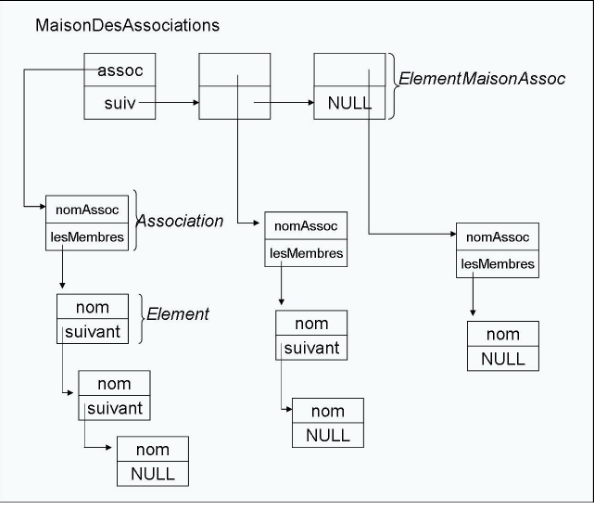

In [38]:
HTML("<div align='center'><img src='C:/Users/Utilisateur/Desktop/s1.png' width='500'></div>")
with open("C:/Users/Utilisateur/Desktop/s1.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

display(Image(data=base64.b64decode(encoded_string)))

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.1 : </b>Donner le code C permettant de definir la maison des associations.</div>

In [ ]:
typedef struct _element {
    char *nom;                  
    struct _element *suivant;   
} Element;

typedef struct _association {
    char *nomAssoc;             
    Element *lesMembres;        
} Association;


typedef struct _element_maison_assoc {
    Association *assoc;                  
    struct _element_maison_assoc *suiv;   
} ElementMaisonAssoc;

typedef struct _maison_des_associations {
    ElementMaisonAssoc *listeAssoc;       
} MaisonDesAssociations;

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.1 : </b>Definir les fonctions suivantes :<br>
— creerAssociation qui cr´ee une association avec son nom et une liste de membres vide.<br>
— ajouterPersonne qui permet d’ajouter un personne en-tˆete de la liste des membres.<br>
— supprimerPersonne qui supprime une personne de la liste des membres</div>

In [ ]:
Association *cree_association(char *nom) {
    Association *A = malloc(sizeof(Association));

    A->nom_asso = strdup(nom);
    A->les_membres = NULL;
    return A;
}

void ajout_une_person(Association *A, char *nom) {
    Element *membre = malloc(sizeof(Element));

    membre->nom = strdup(nom);
    membre->suiv = A->les_membres;  
    A->les_membres = membre;
}

void supprime_une_person(Association *A, char *nom) {
    if (A == NULL || A->les_membres == NULL)
        return;

    Element *courant = A->les_membres;
    Element *precedent = NULL;

   
    while (courant != NULL && strcmp(courant->nom, nom) != 0) {
        precedent = courant;
        courant = courant->suiv;
    }

    if (courant == NULL)
        return;

    if (precedent == NULL)
        A->les_membres = courant->suiv;
    else
        precedent->suiv = courant->suiv;

    free(courant->nom);
    free(courant);
}


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.2 : </b>Definir les fonctions suivantes : <br>
— creerMaisonAssoc qui cree une maison des associations vide.<br>
— ajouterAssociation qui ajoute une association en tete de la liste des associations.<br>
— supprimerAssociation qui supprime une association de la liste des associations.</div>

In [ ]:
MaisonDesAssociations *creerMaisonAssoc() {
    MaisonDesAssociations *m = malloc(sizeof(MaisonDesAssociations));

    m->listeAssoc = NULL;   
    return m;
}

void ajouterAssociation(MaisonDesAssociations *maison, Association *a) {
    if (maison == NULL || a == NULL) return;

    ElementMaisonAssoc *nouvelElem = malloc(sizeof(ElementMaisonAssoc));

    nouvelElem->assoc = a;
    nouvelElem->suiv = maison->listeAssoc;  
    maison->listeAssoc = nouvelElem;
}

void supprimerAssociation(MaisonDesAssociations *maison, const char *nomAssoc) {
    if (maison == NULL || maison->listeAssoc == NULL) return;

    ElementMaisonAssoc *courant = maison->listeAssoc;
    ElementMaisonAssoc *precedent = NULL;

   
    while (courant != NULL && strcmp(courant->assoc->nomAssoc, nomAssoc) != 0) {
        precedent = courant;
        courant = courant->suiv;
    }

    if (courant == NULL) return;

    if (precedent == NULL)
        maison->listeAssoc = courant->suiv;
    else
        precedent->suiv = courant->suiv;

    free(courant->assoc->nomAssoc);
    free(courant->assoc);
    free(courant);
}


<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX2 :</b> Partie 2 : Gestion acyclique <br>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  : </b>Nous allons maintenant ajouter la notion suivante : chaque association est composee de membres qui
peuvent etre soit des personnes physiques, soit des personnes morales. Une association peut donc
elle-meme etre membre d’une autre association.<br> <b>
Q 2.4 Definir une structure permettant de representer soit une personne physique caracterisee par son
nom (char*) et son adresse (char*), soit une personne morale qui aura, bien sur, un nom, une adresse
et une liste de membres. Prevoir de differencier une personne morale d’une personne physique.</div></b>


In [ ]:
typedef struct _asso Association;

typedef struct _membre {
    Association* personnePhysiqueOuMorale;
    struct _membre* suivant;
} MembreAssoc;

struct _asso {
    char* nom;
    char* adresse;
    MembreAssoc* lesMembres; 
}

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.5 : </b>On veut faire un courrier a tous les membres physiques et moraux d’une association A en
considerant que tous les membres d’une association adherentea A sont aussi membres de A. Si l’on
envoie un courrier a toutes les personnes qui sont pointees dans la liste, que peut-il se passer ?.</div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>

Une personne peut recevoir plusieurs fois le courrier. <br>
Il peut y avoir des circuits : A→B→C→A
<br>
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.6 : </b>Comment peut-on remedier aux problemes rencontres dans la question precedente </div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>

S'assurer que la liste des destinataires ne contient pas de doublons.<br>
Avant d'ajouter une asso A dans une asso B, il faut vérifier que B n'est pas déjà dans A
<br>
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 2.7 : </b>On souhaite ecrire une fonction permettant de supprimer un membre de toutes les associations
qui le contiennent. Comment proceder </div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>

Parcourir toutes les associations et suprrimer les pointeurs vers lui (peut être lent).<br>
Maintenir à son niveau la liste des éléments qui le contiennent (occupe plus d'espace mémoire).
<br>
</div> 

<div style="background-color:#fff3cd; border-left:2px solid #ad1457;border-radius:10px;padding:10px; margin-top:10px; ">
     <div style="text-align:center; font-size:30px;"><b>TD5: Les tas</b></div>

</div>

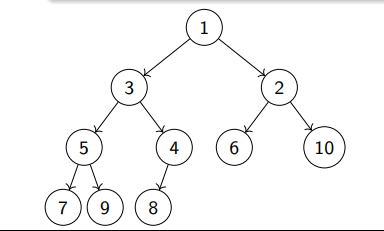

In [39]:
HTML("<div align='center'><img src='C:/Users/Utilisateur/Desktop/s2.png' width='500'></div>")
with open("C:/Users/Utilisateur/Desktop/s2.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

display(Image(data=base64.b64decode(encoded_string)))

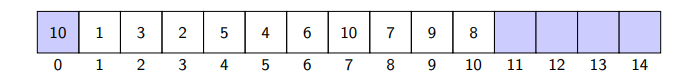

In [41]:
HTML("<div align='center'><img src='C:/Users/Utilisateur/Desktop/s3.png' width='500'></div>")
with open("C:/Users/Utilisateur/Desktop/s3.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

display(Image(data=base64.b64decode(encoded_string)))

In [ ]:
useful link
https://www.cs.usfca.edu/~galles/visualization/Heap.html

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00; padding:10px;">
<b> EX1 :</b>  Rappels sur les tas <br>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.1 : </b>Donner la definition de la structure de donnees abstraite appelee “tas”. </div>


In [ ]:
typedef struct tas {
     int capacite ;
     int * tab_elms ; // si un elmt est definie par sa priorite
} Tas ;

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.2 : </b>En utilisant uniquement l’operation swap(pere, fils), construire le tas obtenu par insertion
successives des entiers <br>[10, 2, 5, 4, 7, 15, 1, 3], la valeur de ces entiers servant directement de cle. </div>


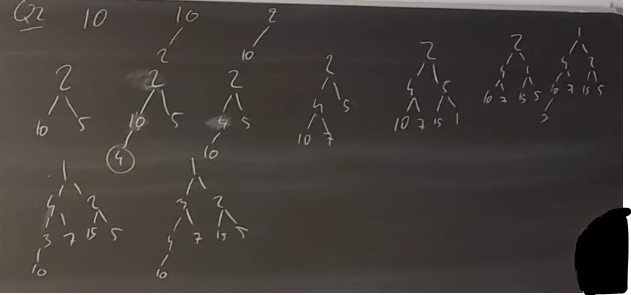

In [42]:
HTML("<div align='center'><img src='C:/Users/Utilisateur/Desktop/s5.png' width='500'></div>")
with open("C:/Users/Utilisateur/Desktop/s5.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

display(Image(data=base64.b64decode(encoded_string)))

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.3 : </b> De la meme maniere, quel arbre obtient-on ensuite en supprimant l’element de plus petite cle ?
D´etailler les etapes. </div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>

Lorsqu’on supprime l’élément de plus petite clé dans un tas min, on place le dernier élément à la position de la racine, puis on compare cette valeur avec ses deux enfants.<br>
On effectue ensuite des échanges (swap) tant que la propriété du tas n’est pas respectée, c’est-à-dire jusqu’à ce que le parent soit inférieur ou égal à ses enfants.
<br>
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.4: </b>  Combien d’elements peut-on avoir dans un tas de hauteur h (en nombre d’arcs)  </div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<b>✅ :</b> <br>

<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6;">
  <h3>Nombre d’éléments dans un tas de hauteur <em>h</em> (en nombre d’arcs)</h3>
  <p>
    Pour un tas binaire (complet) de hauteur <em>h</em> :
  </p>

  <div style="text-align:center; font-size:1.2em; margin:10px 0;">
    <strong>2<sup>h</sup> ≤ n ≤ 2<sup>h+1</sup> − 1</strong>
  </div>

  <ul>
    <li><strong>Minimum :</strong> 2<sup>h</sup> (un seul nœud au dernier niveau)</li>
    <li><strong>Maximum :</strong> 2<sup>h+1</sup> − 1 (tous les niveaux pleins)</li>
  </ul>
</div>

<br>
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.5 : </b> Etant donne n elements `a stocker dans un tas, ecrire h, la hauteur du tas, en fonction de n. </div>


<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">
<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6;">
  <h3>Hauteur <em>h</em> d’un tas en fonction du nombre d’éléments <em>n</em></h3>
  <p>
    Pour un tas binaire (complet) contenant <em>n</em> éléments, la hauteur (en nombre d’arcs) est donnée par :
  </p>

  <div style="text-align:center; font-size:1.2em; margin:10px 0;">
    <strong>h = ⌊log<sub>2</sub>(n)⌋</strong>
  </div>

  <p>
    En d’autres termes, la hauteur d’un tas croît proportionnellement au logarithme du nombre d’éléments qu’il contient.
  </p>
</div>

<br>
</div> 

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b> Q 1.3 : </b> Etant donne n elements `a stocker dans un tas, ecrire h, la hauteur du tas, en fonction de n. </div>

<div style="background-color:#d4edda; border-left:6px solid #155724; padding:10px; margin-top:10px;">

<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6;">
  <h3>Complexité-temps (pire des cas) des opérations sur un tas binaire</h3>

  <p><strong>1️⃣ Insertion d’un élément</strong></p>
  <p>
    Lorsqu’on insère un nouvel élément dans un tas contenant <em>n</em> éléments, 
    il peut être nécessaire de le faire remonter jusqu’à la racine 
    (en effectuant plusieurs opérations <code>swap(père, fils)</code>).
  </p>
  <div style="text-align:center; font-size:1.2em; margin:10px 0;">
    <strong>O(log<sub>2</sub>(n))</strong>
  </div>

  <p><strong>2️⃣ Suppression de l’élément de plus petite clé</strong></p>
  <p>
    Lorsqu’on supprime la racine (l’élément minimal dans un tas min), 
    le dernier élément est déplacé à la racine puis redescend 
    pour rétablir la propriété du tas.  
  </p>
  <div style="text-align:center; font-size:1.2em; margin:10px 0;">
    <strong>O(log<sub>2</sub>(n))</strong>
  </div>

  <p>
    💡 Dans les deux cas, la complexité dépend de la <strong>hauteur du tas</strong>, 
    qui est proportionnelle à <strong>log<sub>2</sub>(n)</strong>.
  </p>
</div>

<br>
</div> 

<div style="background-color:#fff3cd; border-left:6px solid #ffcc00;border-radius:10px; padding:10px;">
<b> EX2 :</b>  Tas ternaire <br>
</div>

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460; padding:10px; margin-top:10px;">
<b>  : </b> fin de r´eduire la hauteur de l’arbre sous-jacent, on propose d’utiliser un tas ternaire a la place d’un
tas binaire. Dans ce type de tas, chaque noeud poss`ede au plus trois fils. La valeur de chaque noeud
est inferieure a celle de ses fils.<b><br>
Q 2.1 Representez le tas ternaire construit a partir des elements [3, 6, 1, 13, 17, 18, 2] </div></b>


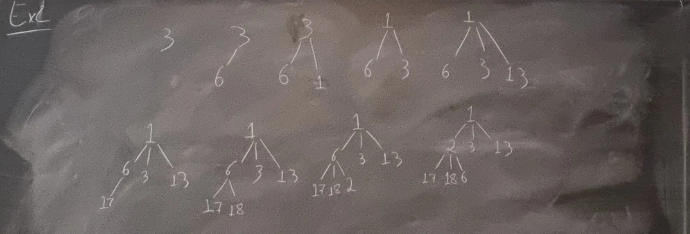

In [43]:
HTML("<div align='center'><img src='C:/Users/Utilisateur/Desktop/s6.png' width='500'></div>")
with open("C:/Users/Utilisateur/Desktop/s6.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

display(Image(data=base64.b64decode(encoded_string)))

<div style="background-color:#d1ecf1; border-left:6px solid #0c5460;border-radius:10px; padding:10px; margin-top:10px;">
<b> Q 2.2 : </b> Etant donne n elements a stocker dans un tas ternaire, ecrire la hauteur h du tas en fonction
de n. Est-ce que l’utilisation d’un tas ternaire ameliore le cout d’insertion dans le pire des cas par
rapport a un tas binaire ? </div>



<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6; background-color:#d8f3dc; padding:20px; border-radius:10px;">
  <h3 style="color:#1b4332;">Tas ternaire (chaque nœud a ≤ 3 enfants)</h3>

  <p><strong>Hauteur <em>h</em> en fonction de <em>n</em> (nombre d’arcs) :</strong></p>
  <div style="text-align:center; font-size:1.2em; margin:10px 0; color:#081c15;">
    <strong>h = ⌊log<sub>3</sub>(n)⌋</strong>
  </div>

  <p><strong>Bornes exactes pour un tas complet :</strong></p>
  <div style="text-align:center; margin:8px 0; color:#1b4332;">
    3<sup>h</sup> ≤ n ≤ (3<sup>h+1</sup> − 1) 
  </div>

  <hr style="border-color:#52b788;">

  <p><strong>Coût (pire des cas) de l’insertion :</strong></p>
  <div style="text-align:center; font-size:1.2em; margin:10px 0; color:#2d6a4f;">
    <strong>O(log<sub>3</sub>(n)) = Θ(log n)</strong>
  </div>

  <p style="color:#081c15;">
    Par rapport à un tas binaire (O(log<sub>2</sub>(n))), le tas ternaire réduit le nombre de niveaux traversés :
    <br>
    <em>log<sub>3</sub>(n) ≈ 0,631 × log<sub>2</sub>(n)</em> (soit ~37% de niveaux en moins).
    <br>
    👉 <strong>Amélioration en facteur constant</strong>, mais la classe de complexité reste Θ(log n).
  </p>
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460;border-radius:10px; padding:10px; margin-top:10px;">
<b> Q 2.3 : </b> En numerotant a partir de 1 les nœuds de l’arbre du haut vers le bas, niveau apres niveau, et
de la gauche vers la droite, quelles relations peut-on ´etablir entre le numero d’un nœud et ceux de ses
trois fils ? Sachant que l’arbre est complet, d´ecrire comment stocker un tas ternaire dans un tableau
et ecrire les fonctions necessaires a sa gestion. </div>


<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6;border-left:6px solid #0c5460; background-color:#d8f3dc; padding:20px; border-radius:10px;">

  <h3 style="color:#1b4332;">Représentation et gestion d’un tas ternaire</h3>

  <h4 style="color:#2d6a4f;">1️⃣ Numérotation des nœuds</h4>
  <p>
    On numérote les nœuds à partir de <strong>1</strong> (racine), 
    en parcourant l’arbre de <strong>haut en bas</strong> et de <strong>gauche à droite</strong>.
  </p>

  <p>Pour un nœud d’indice <em>i</em> :</p>
  <div style="text-align:center; font-size:1.1em; margin:10px 0; color:#081c15;">
    <strong>
      Père&nbsp;: ⌊(i−1)/3⌋ <br>
      Fils&nbsp;1&nbsp;: 3i − 1&nbsp;&nbsp;&nbsp;&nbsp;
      Fils&nbsp;2&nbsp;: 3i&nbsp;&nbsp;&nbsp;&nbsp;
      Fils&nbsp;3&nbsp;: 3i + 1
    </strong>
  </div>

  <p>
    Exemple : pour <em>i = 2</em>, ses fils sont les indices <em>5, 6, 7</em>.
  </p>

  <hr style="border-color:#52b788;">

  <h4 style="color:#2d6a4f;">2️⃣ Stockage dans un tableau</h4>
  <p>
    Comme le tas ternaire est un <strong>arbre complet</strong>, on le stocke simplement dans un tableau :
  </p>

  <ul>
    <li>La racine est à l’indice <code>1</code>.</li>
    <li>Les fils d’un nœud <code>i</code> se trouvent aux indices <code>3i−1</code>, <code>3i</code> et <code>3i+1</code> s’ils existent.</li>
    <li>Le père d’un nœud <code>i</code> se trouve à l’indice <code>(i−1)/3</code> (division entière).</li>
  </ul>

  <hr style="border-color:#52b788;">

  <h4 style="color:#2d6a4f;">3️⃣ Fonctions de gestion (pseudo-C)</h4>

  <pre style="background:#b7e4c7; padding:10px; border-radius:8px; color:#081c15;">
int pere(int i) { return (i - 1) / 3; }

int fils_gauche(int i) { return 3 * i - 1; }
int fils_milieu(int i) { return 3 * i; }
int fils_droit(int i)  { return 3 * i + 1; }
  </pre>

  <p>
    Ces fonctions permettent d’accéder facilement aux relations dans le tableau et de réaliser les opérations 
    <strong>insertion</strong>, <strong>suppression</strong> et <strong>réorganisation (heapify)</strong> du tas ternaire.
  </p>
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460;border-radius:10px; padding:10px; margin-top:10px;">
<b> Q 2.4 : </b> En utilisant les relations definies precedemment, ecrire une fonction qui supprime et retourne
le plus petit element d’un tas ternaire contenant des entiers.<br>
Note Afin de maintenir une structure d’arbre ternaire tasse a gauche, il faut remplacer la racine par
la feuille qui se trouve a l’extremite droite. </div>


<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6; background-color:#d8f3dc; padding:20px; border-radius:10px;">

  <h3 style="color:#1b4332;">Suppression du plus petit élément d’un tas ternaire (min-heap)</h3>

  <p>
    Lorsqu’on supprime la racine (le plus petit élément), on remplace sa valeur par la 
    <strong>feuille la plus à droite</strong> (dernier élément du tableau), puis on effectue une 
    <strong>descente (heapify)</strong> pour rétablir la propriété du tas.
  </p>

  <pre style="background:#b7e4c7; padding:10px; border-radius:8px; color:#081c15;">
#include &lt;stdio.h&gt;
#include &lt;stdlib.h&gt;
#include <stdio.h>

typedef struct tas {
    int* tab;   // tab[0] = n (nombre d'éléments)
} Tas_Ternaire;

int supprimerRacine(Tas_Ternaire* tas)
{
    int nb = tas->tab[0];
    if (nb == 0) return -1; // tas vide

    int racine = tas->tab[1];
    int feuille = tas->tab[nb];
    int n = nb - 1;
    tas->tab[0] = n;

    int pos = 1;
    int min, fils;

    while ((3 * pos - 1) <= n)
    {
        // Trouver le plus petit des enfants existants
        min = tas->tab[3 * pos - 1];
        fils = -1;  // gauche

        if ((3 * pos <= n) && (min > tas->tab[3 * pos])) {
            min = tas->tab[3 * pos];
            fils = 0;  // milieu
        }

        if ((3 * pos + 1 <= n) && (min > tas->tab[3 * pos + 1])) {
            min = tas->tab[3 * pos + 1];
            fils = 1;  // droite
        }

        // Si le plus petit enfant est plus petit que la feuille
        if (min < feuille) {
            tas->tab[pos] = min;

            // mise à jour correcte de pos selon le fils choisi
            if (fils == -1) pos = 3 * pos - 1;
            else if (fils == 0) pos = 3 * pos;
            else pos = 3 * pos + 1;
        }
        else {
            break;
        }
    }

    tas->tab[pos] = feuille;  // replacer la feuille
    tas->tab[nb] = racine;    // sauvegarde ancienne racine (optionnel)
    return racine;
}
 </pre>

  <p style="color:#081c15;">
    🔹 <strong>Complexité :</strong> O(log<sub>3</sub>(n))  
    <br>
    🔹 <strong>Principe :</strong> La descente compare le parent à ses trois enfants à chaque niveau.  
    <br>
    🔹 <strong>Remplacement :</strong> la racine est remplacée par la feuille la plus à droite (dernier élément du tableau).
  </p>
</div>


<div style="background-color:#d1ecf1; border-left:6px solid #0c5460;border-radius:10px; padding:10px; margin-top:10px;">
<b> Q 2.4 : </b> Quelle est la complexite-temps pire cas de la suppression d’un element dans un tas ternaire
contenant n elements. </div>


<div style="font-family: system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif; line-height:1.6; background-color:#d8f3dc; padding:20px; border-radius:10px;">
  <h3 style="color:#1b4332;">Complexité-temps (pire cas) de la suppression dans un tas ternaire</h3>
  <p>
    Lorsqu’on supprime un élément (ex.&nbsp;: la racine) dans un tas ternaire contenant <em>n</em> éléments&nbsp;:
  </p>
  <ul>
    <li>On remplace la racine par la dernière feuille.</li>
    <li>On effectue une <strong>descente (heapify)</strong> en comparant le parent avec ses trois enfants.</li>
  </ul>

  <div style="text-align:center; font-size:1.2em; margin:10px 0; color:#081c15;">
    <strong>Complexité&nbsp;: O(log<sub>3</sub>(n))</strong>
  </div>

  <p style="color:#081c15;">
    💡 Le nombre de niveaux d’un tas ternaire est proportionnel à <em>log<sub>3</sub>(n)</em>, 
    donc la classe de complexité reste Θ(log&nbsp;n), mais avec un facteur constant plus faible que pour un tas binaire.
  </p>
</div>
